# Spaceship Titanic — End-to-end ML pipeline

This notebook contains the full end-to-end pipeline I used in the session: data loading, EDA, feature engineering, preprocessing, a scikit-learn pipeline with a RandomForest, quick evaluation, and saving artifacts.

You can open and run cells interactively. Some heavy hyperparameter search cells are included but commented or limited to avoid excessive compute when run unintentionally.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt

# Path to training CSV that was uploaded in the session
DATA_PATH = "train.csv"
print('Expecting train CSV at:', DATA_PATH)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found at {DATA_PATH} — upload it or change DATA_PATH")

df = pd.read_csv(DATA_PATH)
print('Loaded dataset shape:', df.shape)


Expecting train CSV at: train.csv
Loaded dataset shape: (8693, 14)


In [2]:
# Quick preview
display(df.head())
display(df.info())
display(df.isna().sum().sort_values(ascending=False))


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


None

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

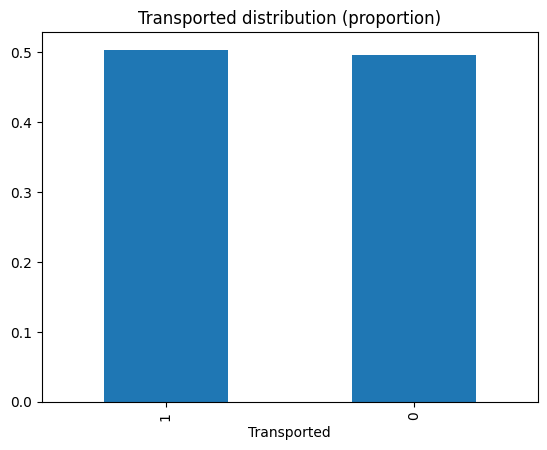

In [3]:
# Target
target_col = 'Transported'
if target_col in df.columns:
    y = df[target_col].map({True:1, False:0})
    X = df.drop(columns=[target_col])
else:
    raise ValueError("Expected target column 'Transported' in uploaded CSV.")

import matplotlib.pyplot as plt
plt.figure()
y.value_counts(normalize=True).plot(kind='bar')
plt.title('Transported distribution (proportion)')
plt.show()


In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Transformations:
     - parse Cabin -> deck, cabin_num, side
     - extract group id from PassengerId and group size/is_alone
     - numeric-cast service columns and sum to total_spend
     - cast Age, CryoSleep, VIP to numeric flags
    """
    def __init__(self):
        self.service_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        if 'PassengerId' in X.columns:
            X['PassengerId'] = X['PassengerId'].astype(str)
            X['group'] = X['PassengerId'].str.split('_').str[0]
            X['group_size'] = X.groupby('group')['PassengerId'].transform('count')
            X['is_alone'] = (X['group_size'] == 1).astype(int)
        else:
            X['group_size'] = 1
            X['is_alone'] = 1
        if 'Cabin' in X.columns:
            cabin = X['Cabin'].fillna('Unknown/0/Unknown').astype(str)
            parts = cabin.str.split('/', expand=True)
            X['deck'] = parts[0].replace('Unknown', np.nan)
            X['cabin_num'] = pd.to_numeric(parts[1], errors='coerce')
            X['side'] = parts[2].replace('Unknown', np.nan)
        else:
            X['deck'] = np.nan
            X['cabin_num'] = np.nan
            X['side'] = np.nan
        for col in self.service_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0.0)
            else:
                X[col] = 0.0
        X['total_spend'] = X[self.service_cols].sum(axis=1)
        if 'Age' in X.columns:
            X['Age'] = pd.to_numeric(X['Age'], errors='coerce')
        else:
            X['Age'] = np.nan
        for col in ['CryoSleep','VIP']:
            if col in X.columns:
                X[col] = X[col].map({True:1, False:0})
            else:
                X[col] = np.nan
        return X


In [5]:
# Preprocessing and pipeline
fe = FeatureEngineer()
X_fe = fe.transform(X)

numeric_features = ['Age','cabin_num','group_size','total_spend','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
categorical_features = ['HomePlanet','Destination','deck','side']
binary_like = ['CryoSleep','VIP','is_alone']

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
binary_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('bin', binary_transformer, binary_like)
], remainder='drop')

clf = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=1, class_weight='balanced')
pipeline = Pipeline(steps=[('fe', fe), ('pre', preprocessor), ('clf', clf)])

In [6]:
# Train/validate split, fit, evaluate
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_val)
y_proba = pipeline.predict_proba(X_val)[:,1]
print('Validation accuracy:', accuracy_score(y_val, y_pred))
print('Validation ROC AUC:', roc_auc_score(y_val, y_proba))
print('\nClassification report:\n', classification_report(y_val, y_pred))


Validation accuracy: 0.8067855089131685
Validation ROC AUC: 0.8945505748768499

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       863
           1       0.83      0.77      0.80       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



In [7]:
# Save artifacts
MODEL_PATH = 'spaceship_pipeline_rf_simple.joblib'
joblib.dump(pipeline, MODEL_PATH)
print('Saved model to:', MODEL_PATH)

VAL_PRED_PATH = 'val_predictions_simple.csv'
val_out = X_val.copy()
val_out['true'] = y_val.values
val_out['pred'] = y_pred
val_out['proba'] = y_proba
val_out.to_csv(VAL_PRED_PATH, index=False)
print('Saved val predictions to:', VAL_PRED_PATH)


Saved model to: spaceship_pipeline_rf_simple.joblib
Saved val predictions to: val_predictions_simple.csv


## Optional: hyperparameter search (commented out by default)

Uncomment and run if you want to perform randomized tuning. Be careful with `n_jobs=-1` or large `n_iter` values on small machines.


In [8]:
# from sklearn.model_selection import RandomizedSearchCV
# param_dist = {
#     'clf__n_estimators': [100, 200, 400],
#     'clf__max_depth': [6, 10, 20, None],
#     'clf__min_samples_split': [2, 5, 10],
#     'clf__min_samples_leaf': [1, 2, 4]
# }
# rs = RandomizedSearchCV(pipeline, param_dist, n_iter=12, cv=5, scoring='roc_auc', random_state=42, n_jobs=1)
# rs.fit(X_train, y_train)
# print(rs.best_params_, rs.best_score_)
